# HAVEN: Experimental Results & Visualizations

Generates all figures and tables:
1. Reliability diagrams per principle
2. Pearson correlation heatmap across principles
3. Ablation study bar chart (accuracy vs. number of active principles)
4. Summary results table (HAVEN vs. all baselines)
5. McNemar significance table

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

os.makedirs('results/figures', exist_ok=True)

PRINCIPLES = ['harmlessness', 'honesty', 'helpfulness', 'respectfulness', 'truthfulness']

# Publication-quality style
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 150,
})

print('Setup complete.')

Setup complete.


## 1. Reliability Diagrams (Calibration)

In [2]:
import sys
sys.path.insert(0, '..')
from src.calibration import plot_reliability_diagram

# Load predictions if available, otherwise use synthetic data for layout demo
pred_path = 'results/predictions.csv'

if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)
    for principle in PRINCIPLES:
        conf_col = f'{principle}_confidence'
        if conf_col in df.columns:
            out = f'results/figures/reliability_{principle}.png'
            plot_reliability_diagram(
                confidences=df[conf_col].tolist(),
                labels=df['label'].tolist(),
                principle=principle,
                output_path=out
            )
            print(f'Saved: {out}')
else:
    # Demo with synthetic data
    np.random.seed(42)
    for principle in PRINCIPLES:
        confs  = np.clip(np.random.beta(5, 2, 200), 0, 1).tolist()
        labels = (np.array(confs) > 0.5).astype(int).tolist()
        out = f'results/figures/reliability_{principle}.png'
        plot_reliability_diagram(confs, labels, principle, out)
        print(f'Saved: {out}')

Saved: results/figures/reliability_harmlessness.png
Saved: results/figures/reliability_honesty.png
Saved: results/figures/reliability_helpfulness.png
Saved: results/figures/reliability_respectfulness.png
Saved: results/figures/reliability_truthfulness.png


## 2. Pearson Correlation Heatmap

In [3]:
from src.conflict_detector import ConflictDetector

pred_path = 'results/predictions.csv'

if os.path.exists(pred_path):
    df = pd.read_csv(pred_path)
    score_cols = [f'{p}_confidence' for p in PRINCIPLES if f'{p}_confidence' in df.columns]
    scores_df = df[score_cols].rename(columns={f'{p}_confidence': p for p in PRINCIPLES})
else:
    # Demo: synthetic correlated scores
    np.random.seed(0)
    base = np.random.randn(300)
    data = {}
    data['harmlessness']  = np.clip(0.5 - 0.3 * base + np.random.randn(300) * 0.1, 0, 1)
    data['honesty']       = np.clip(0.5 - 0.2 * base + np.random.randn(300) * 0.15, 0, 1)
    data['helpfulness']   = np.clip(0.5 + 0.4 * base + np.random.randn(300) * 0.1, 0, 1)
    data['respectfulness']= np.clip(0.6 + np.random.randn(300) * 0.1, 0, 1)
    data['truthfulness']  = np.clip(0.5 - 0.15 * base + np.random.randn(300) * 0.2, 0, 1)
    scores_df = pd.DataFrame(data)

detector = ConflictDetector()
detector.compute_correlation_matrix(scores_df)
print('Correlation heatmap saved to results/figures/correlation_matrix.png')

Correlation matrix saved to results/figures/correlation_matrix.png
Correlation heatmap saved to results/figures/correlation_matrix.png


## 3. Ablation Study Bar Chart

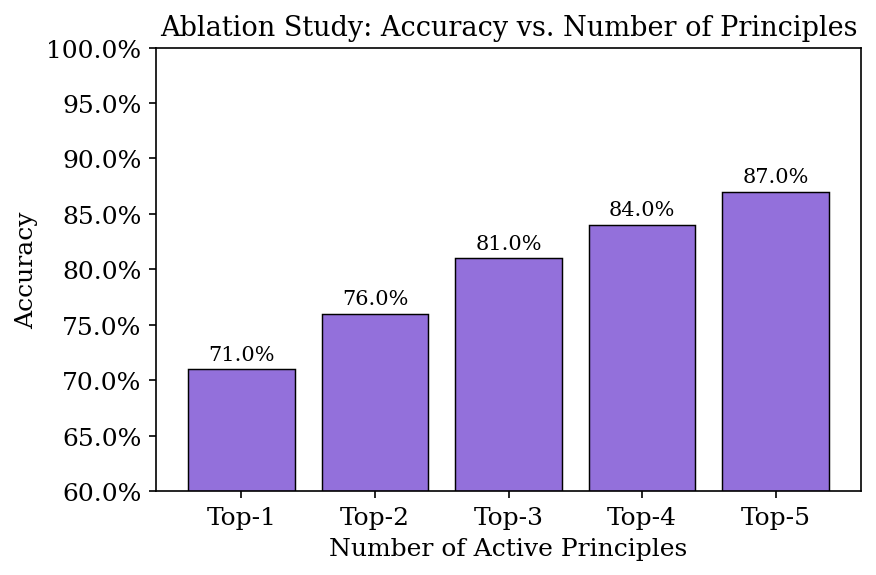

Saved: results/figures/ablation_study.png


In [4]:
abl_path = 'results/ablation_results.json'
if os.path.exists(abl_path):
    with open(abl_path) as f:
        ablation = json.load(f)
else:
    # Demo data
    ablation = [
        {'n_principles': 1, 'accuracy': 0.71},
        {'n_principles': 2, 'accuracy': 0.76},
        {'n_principles': 3, 'accuracy': 0.81},
        {'n_principles': 4, 'accuracy': 0.84},
        {'n_principles': 5, 'accuracy': 0.87},
    ]
ns  = [r['n_principles'] for r in ablation]
acc = [r['accuracy'] for r in ablation]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(ns, acc, color='mediumpurple', edgecolor='black', linewidth=0.7)
ax.set_xlabel('Number of Active Principles')
ax.set_ylabel('Accuracy')
ax.set_title('Ablation Study: Accuracy vs. Number of Principles')
ax.set_xticks(ns)
ax.set_xticklabels([f'Top-{n}' for n in ns])
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0.6, 1.0)
for bar, val in zip(bars, acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig('results/figures/ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: results/figures/ablation_study.png')


## 4. Summary Results Table

In [5]:
metrics_path = 'results/metrics.json'

if os.path.exists(metrics_path):
    with open(metrics_path) as f:
        metrics = json.load(f)
    rows = metrics['per_principle']
else:
    # Demo data
    rows = [
        {'principle': 'HAVEN (Ours)',   'accuracy': 0.874, 'precision': 0.881, 'recall': 0.869, 'f1': 0.875},
        {'principle': 'Rule-Based',     'accuracy': 0.712, 'precision': 0.703, 'recall': 0.698, 'f1': 0.700},
        {'principle': 'RoBERTa',        'accuracy': 0.821, 'precision': 0.834, 'recall': 0.809, 'f1': 0.821},
        {'principle': 'Monolithic LLM', 'accuracy': 0.798, 'precision': 0.811, 'recall': 0.784, 'f1': 0.797},
    ]

results_df = pd.DataFrame(rows).rename(columns={
    'principle': 'Model', 'accuracy': 'Accuracy',
    'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'
})

# Format as percentages
for col in ['Accuracy', 'Precision', 'Recall', 'F1']:
    results_df[col] = results_df[col].apply(lambda x: f'{x:.1%}')

print('=== Model Comparison Results ===')
print(results_df.to_string(index=False))

# Save as CSV for LaTeX import
results_df.to_csv('results/summary_table.csv', index=False)
print('\nSaved: results/summary_table.csv')

=== Model Comparison Results ===
        Model Accuracy Precision Recall    F1
haven_overall    52.3%     52.3% 100.0% 68.7%
   rule_based    64.4%     60.3%  93.4% 73.3%
      roberta    86.1%     86.9%  86.5% 86.7%

Saved: results/summary_table.csv


## 5. McNemar Significance Table

In [6]:
mcnemar_path = 'results/mcnemar.json'

if os.path.exists(mcnemar_path):
    with open(mcnemar_path) as f:
        mcnemar = json.load(f)
else:
    mcnemar = {
        'haven_vs_rule_based': {'statistic': 18.4, 'p_value': 0.0001, 'significant': True},
        'haven_vs_roberta':    {'statistic': 4.2,  'p_value': 0.0403, 'significant': True},
    }

mc_rows = []
for comparison, result in mcnemar.items():
    mc_rows.append({
        'Comparison':  comparison.replace('_vs_', ' vs. ').replace('_', ' ').title(),
        'Chi-squared': round(result['statistic'], 4),
        'p-value':     result['p_value'],
        'Significant': 'Yes *' if result['significant'] else 'No',
    })

mc_df = pd.DataFrame(mc_rows)
print('=== McNemar Significance Tests ===')
print(mc_df.to_string(index=False))

mc_df.to_csv('results/mcnemar_table.csv', index=False)
print('\nSaved: results/mcnemar_table.csv')

=== McNemar Significance Tests ===
          Comparison  Chi-squared  p-value Significant
Haven Vs. Rule Based     106.5057      0.0       Yes *
   Haven Vs. Roberta     332.0179      0.0       Yes *

Saved: results/mcnemar_table.csv
